In [1]:
### RESULTS ARE IN: "dpa_tuning3_starting11122025_v4_data" ###

# -> also compare with tuning5 that includes pene


In [1]:
import json
import subprocess
import re
from itertools import product
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
output_dir = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning6_starting17022026_v6_data/"
# 1) Define your coordinate values
coords = {
    'latent_dim':    [50, 100],
    'encoder':       ['learnable'],
    'hidden_dim_NN': [50, 100],
    'num_layers_NN': [4, 6],
    'noise_dim_dec': [5, 20, 100],
    'hidden_dim_lm': [50, 100],
    'noise_dim_lm':  [20, 100],
    'lamb':          [0.5, 1.0],
    'epoch':         np.arange(1, 101),          # 0 … 100 inclusive
    'batch_norm':    ["True", "False"],
    'alpha':         [1.0, 1.5],
    'learn_rate':    [0.0001, 0.00005],
    'mode':          ['train', 'test'],
    'loss':          ['Total loss','Total S1','Total S2',
                      'DPA NRGY','DPA s1','DPA s2',
                      'LM NRGY','LM S1','LM S2']
}


#save_dir = f"{settings['output_dir']}_{latent_dim}_{num_layers}_{hidden_dim}_{noise_dim_dec}_{in_dim_lm}_{noise_dim_lm}_{num_layers_lm}_{hidden_dim_lm}_encoderis{encoder}_lambda{lam}/"

In [3]:
# Generate all combinations as tuples
combos = list(product(
    coords['latent_dim'],
    coords['encoder'],
    coords['hidden_dim_NN'],
    coords['num_layers_NN'],
    coords['noise_dim_dec'],
    coords['hidden_dim_lm'],
    coords['noise_dim_lm'],
    coords['lamb'],
    coords['batch_norm'],
    coords['alpha'],
    coords['learn_rate']
))

# If you prefer a list of dicts:
param_names = [
    "latent_dim", "encoder", "hidden_dim_NN", "num_layers_NN",
    "noise_dim_dec", "hidden_dim_lm", "noise_dim_lm", "lambda", "batch_norm", "alpha", "learn_rate"
]
combo_dicts = [dict(zip(param_names, vals)) for vals in combos]

In [4]:
combo_dicts

[{'latent_dim': 50,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 50,
  'noise_dim_lm': 20,
  'lambda': 0.5,
  'batch_norm': 'True',
  'alpha': 1.0,
  'learn_rate': 0.0001},
 {'latent_dim': 50,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 50,
  'noise_dim_lm': 20,
  'lambda': 0.5,
  'batch_norm': 'True',
  'alpha': 1.0,
  'learn_rate': 5e-05},
 {'latent_dim': 50,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 50,
  'noise_dim_lm': 20,
  'lambda': 0.5,
  'batch_norm': 'True',
  'alpha': 1.5,
  'learn_rate': 0.0001},
 {'latent_dim': 50,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 50,
  'noise_dim_lm': 20,
  'lambda': 0.5,
  'batch_norm': 'True',
  'alpha': 1.5,
  'learn_rate': 5e-05},
 {'latent_dim': 50,
  'encoder': 'learnabl

In [5]:
def load_and_validate(path, validator):
    """
    Load the file at `path` and run `validator(obj)`.
    Raise FileNotFoundError if missing, or ValueError if validator fails.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"No such file: {path}")
    
    # Example for JSON; swap out for pd.read_csv, pickle.load, etc.
    #with open(path, 'r') as f:
        #obj = json.load(f)
    df = pd.read_csv(
            path,
            skipinitialspace=True,
            dtype={'Epoch': str}
        )

    if not validator(df):
        raise ValueError(f"Validation failed for file: {path}")
    df_data = get_train_test(df)
    return df_data

def get_train_test(df):
    # split into Train vs Test
    is_train = df['Epoch'].str.startswith('Train')
    is_test  = df['Epoch'].str.startswith('Test')

    train_df = df[is_train].reset_index(drop=True)
    test_df  = df[is_test].reset_index(drop=True)

    # get numeric columns and arrays
    numeric_cols = df.columns.drop('Epoch')
    train_array = train_df[numeric_cols].to_numpy()
    test_array  = test_df[numeric_cols].to_numpy()
    return train_array, test_array

# --- Your custom validation function ---
def col_no(df):
    
    #train_array, test_array = get_train_test(df)
    
    #if test_array.shape[0] == 100:
    #if test_array.shape[0] > 0:
    #    prop = True
    #else:
    #    print(f"[{i}] Test array length: {test_array.shape[0]}")
    #    prop = False
    return True
    

In [6]:
# 2) Create an empty Dataset filled with NaNs
ds = xr.Dataset(
    coords={k: ( [k], v ) for k, v in coords.items()},
    data_vars={
        'value': ( list(coords.keys()), 
                   np.full([len(v) for v in coords.values()], np.nan) )
    }
)
# dims of ds['value'] are in the order of coords.keys()

# 3) Function to parse hyperparameters from filename
def parse_filename(fname):
    """
    example filename:
    _10_4_50_10_1001_20_2_50_encoderislearnable_lambda0.0
    _latentdim(0)_numlayers(1)_hiddendim(2)_noisedimdec(3)_indimlm(4)_noisedimlm(5)_numlayerslm(6)_hiddendimlm(7)_encoder(8)_lambda(9)
    Expect filenames like:
      '..._10_PCA_50_4_5_20_20_20_0.5.txt'
    in exactly the same order as coords (except epoch/mode/loss).
    """
    stem = Path(fname).name
    print(stem)
    parts = stem.split('_')
    print("Parts:", parts)
    #print(str(parts[8+1].split('is')[1]))
    print("lambda:", parts[9+1].split('bda')[1])
    return {
        'latent_dim':    int(parts[0+1]),
        'num_layers_NN': int(parts[1+1]),
        'hidden_dim_NN': int(parts[2+1]),
        'noise_dim_dec': int(parts[3+1]),
        'hidden_dim_lm': int(parts[7+1]),
        'noise_dim_lm':  int(parts[5+1]),
        'encoder':       str(parts[8+1].split('is')[1]),
        'lambda':        float(parts[9+1].split('bda')[1]),
        'batch_norm':    str(parts[12+1].split('bnis')[1]),
        'alpha':         float(parts[10+1].split('lpha')[1]),
        'learn_rate':            float(parts[13+1].split('lr')[1])
    }
    


In [11]:
i = 1
while i < 1536:
    print(i)
    save_path = (
        f"{output_dir}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderislearnable_"
        #f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}_alpha{combo_dicts[i]['alpha']}_bs128_bnis{combo_dicts[i]['batch_norm']}_lr{combo_dicts[i]['learn_rate']}/log.txt"
    )
    try:
        df = load_and_validate(save_path, col_no)
        file_path = Path(save_path)
        
        train_losses = df[0]
        #if np.isnan(train_losses).any():
        #    print("Contains NaN?", np.isnan(train_losses).any(), np.isnan(train_losses).sum())
        test_losses = df[1]
        #if np.isnan(test_losses).any():
        #    print("Contains NaN?", np.isnan(test_losses).any(), np.isnan(test_losses).sum())
    
        params = parse_filename(file_path.parent)
    
        ###
        n_train = train_losses.shape[0]
        n_test = test_losses.shape[0]
        
        # train values
        target_train = ds['value'].loc[
            dict(
                latent_dim=params['latent_dim'],
                encoder=params['encoder'],
                hidden_dim_NN=params['hidden_dim_NN'],
                num_layers_NN=params['num_layers_NN'],
                noise_dim_dec=params['noise_dim_dec'],
                hidden_dim_lm=params['hidden_dim_lm'],
                noise_dim_lm=params['noise_dim_lm'],
                lamb=params['lambda'],
                alpha=params['alpha'],
                batch_norm=params['batch_norm'],
                learn_rate=params['learn_rate'],
                mode="train",
            )
        ] 
        target_train[:n_train, :] = train_losses
        
        # test values
        target_test = ds['value'].loc[
            dict(
                latent_dim=params['latent_dim'],
                encoder=params['encoder'],
                hidden_dim_NN=params['hidden_dim_NN'],
                num_layers_NN=params['num_layers_NN'],
                noise_dim_dec=params['noise_dim_dec'],
                hidden_dim_lm=params['hidden_dim_lm'],
                noise_dim_lm=params['noise_dim_lm'],
                lamb=params['lambda'],
                alpha=params['alpha'],
                batch_norm=params['batch_norm'],
                learn_rate=params['learn_rate'],
                mode="test",
            )
        ] 
        target_test[:n_test, :] = test_losses
    except FileNotFoundError:
        print("File not found, continuing...")
        continue

    ###
    finally:
        i += 1

1
_50_4_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05
Parts: ['', '50', '4', '50', '5', '1001', '20', '2', '50', 'encoderislearnable', 'lambda0.5', 'alpha1.0', 'bs128', 'bnisTrue', 'lr5e-05']
lambda: 0.5
2
_50_4_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisTrue_lr0.0001
Parts: ['', '50', '4', '50', '5', '1001', '20', '2', '50', 'encoderislearnable', 'lambda0.5', 'alpha1.5', 'bs128', 'bnisTrue', 'lr0.0001']
lambda: 0.5
3
_50_4_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisTrue_lr5e-05
Parts: ['', '50', '4', '50', '5', '1001', '20', '2', '50', 'encoderislearnable', 'lambda0.5', 'alpha1.5', 'bs128', 'bnisTrue', 'lr5e-05']
lambda: 0.5
4
File not found, continuing...
5
File not found, continuing...
6
File not found, continuing...
7
File not found, continuing...
8
_50_4_50_5_1001_20_2_50_encoderislearnable_lambda1.0_alpha1.0_bs128_bnisTrue_lr0.0001
Parts: ['', '50', '4', '50', '5', '1001', '20', '2', '50', 'encoderisle

In [8]:
ds.value.isnull().sum().item()


2152674

In [9]:
192*100*16*9

2764800

In [12]:
ds.value

<xarray.DataArray 'value' (latent_dim: 2, encoder: 1, hidden_dim_NN: 2,
                           num_layers_NN: 2, noise_dim_dec: 3,
                           hidden_dim_lm: 2, noise_dim_lm: 2, lamb: 2,
                           epoch: 100, batch_norm: 2, alpha: 2, learn_rate: 2,
                           mode: 2, loss: 9)> Size: 22MB
array([[[[[[[[[[[[[[     nan,      nan,      nan, ...,
                         nan,      nan,      nan],
                   [     nan,      nan,      nan, ...,
                         nan,      nan,      nan]],

                  [[ 91.2082, 119.9982,  65.9343, ...,
                     50.9553,  69.96  ,  38.0094],
                   [ 71.7901, 110.3844,  77.1887, ...,
                     46.6786,  68.466 ,  43.5749]]],


                 [[[ 99.0462, 114.6738,  82.3597, ...,
                     43.9569,  68.4507,  48.9876],
                   [ 55.7171, 105.1492,  98.8641, ...,
                     35.0019,  65.2108,  60.4179]],

                  [[118.6942, 122.5997,  67.4676, ...,
                     51.4547,  70.8882,  38.8671],
                   [ 75.1521, 111.0455,  71.7868, ...,
                     47.7339,  68.0104,  40.5532]]]],
...
                         nan,      nan,      nan],
                   [     nan,      nan,      nan, ...,
                         nan,      nan,      nan]],

                  [[     nan,      nan,      nan, ...,
                         nan,      nan,      nan],
                   [     nan,      nan,      nan, ...,
                         nan,      nan,      nan]]],


                 [[[     nan,      nan,      nan, ...,
                         nan,      nan,      nan],
                   [     nan,      nan,      nan, ...,
                         nan,      nan,      nan]],

                  [[     nan,      nan,      nan, ...,
                         nan,      nan,      nan],
                   [     nan,      nan,      nan, ...,
                         nan,      nan,      nan]]]]]]]]]]]]]],
      shape=(2, 1, 2, 2, 3, 2, 2, 2, 100, 2, 2, 2, 2, 9))
Coordinates: (12/14)
  * latent_dim     (latent_dim) int64 16B 50 100
  * encoder        (encoder) <U9 36B 'learnable'
  * hidden_dim_NN  (hidden_dim_NN) int64 16B 50 100
  * num_layers_NN  (num_layers_NN) int64 16B 4 6
  * noise_dim_dec  (noise_dim_dec) int64 24B 5 20 100
  * hidden_dim_lm  (hidden_dim_lm) int64 16B 50 100
    ...             ...
  * epoch          (epoch) int64 800B 1 2 3 4 5 6 7 8 ... 94 95 96 97 98 99 100
  * batch_norm     (batch_norm) <U5 40B 'True' 'False'
  * alpha          (alpha) float64 16B 1.0 1.5
  * learn_rate     (learn_rate) float64 16B 0.0001 5e-05
  * mode           (mode) <U5 40B 'train' 'test'
  * loss           (loss) <U10 360B 'Total loss' 'Total S1' ... 'LM S1' 'LM S2'

In [13]:
# distinguish: 
# - bn
# - lr
# - 



# plot all
loss_sub_all = ds.value.sel(mode='test', loss='LM NRGY', batch_norm='True')
config_dims_all = ["latent_dim", "encoder", "hidden_dim_NN", "num_layers_NN", "noise_dim_dec", "hidden_dim_lm", "noise_dim_lm", "lamb", "alpha", "learn_rate"]#, "batch_norm"]
stacked_all = loss_sub_all.stack(config=config_dims_all)
stacked_all

# distinguish
loss_sub_lr0001 = ds.value.sel(
             #latent_dim=50,
             #hidden_dim_NN = 100,
             #num_layers_NN = 4,
             #noise_dim_dec,
             #hidden_dim_lm = 100,
             #noise_dim_lm = 100,
             #lamb,
             #epoch, 
             #alpha=1.0,
             learn_rate=0.0001,
             mode='test',
             loss='LM NRGY'
            )

loss_sub_lr00005 = ds.value.sel(
             #latent_dim=50,
             #hidden_dim_NN = 100,
             #num_layers_NN = 4,
             #noise_dim_dec,
             #hidden_dim_lm = 100,
             #noise_dim_lm = 100,
             #lamb,
             #epoch, 
             #alpha=1.0,
             learn_rate=0.00005,
             mode='test',
             loss='LM NRGY'
            )

config_dims = ["encoder", "noise_dim_dec", "lamb", "batch_norm", "hidden_dim_NN", "num_layers_NN", "hidden_dim_lm", "noise_dim_lm", "alpha", "latent_dim"]#, "learn_rate"]

stacked_0001 = loss_sub_lr0001.stack(config=config_dims)
stacked_00005 = loss_sub_lr00005.stack(config=config_dims)
stacked_0001.shape

(100, 768)

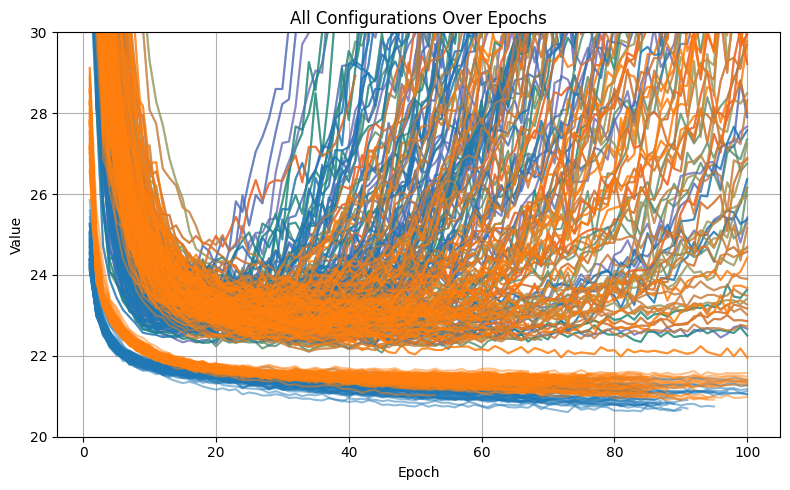

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(stacked_all.sizes["config"]):
    coords = stacked_all.config[i].item()  # tuple of coordinate values
    #label = ", ".join(f"{dim}={val}" for dim, val in zip(config_dims_all, coords))

    ax.plot(
        stacked_all["epoch"],
        stacked_all.isel(config=i),
        alpha=0.7,
        #label=label
    )

for i in range(stacked_0001.sizes["config"]):
    ax.plot(
    stacked_0001["epoch"],
    stacked_0001.isel(config=i),
    alpha=0.5,
    color="tab:blue"
    )



for i in range(stacked_00005.sizes["config"]):
    ax.plot(
    stacked_00005["epoch"],
    stacked_00005.isel(config=i),
    alpha=0.5,
    color="tab:orange"
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Value")
ax.set_title("All Configurations Over Epochs")
ax.grid()

# Place legend outside
#ax.legend(
#    bbox_to_anchor=(1.02, 1),
#    loc="upper left",
#    borderaxespad=0.,
#    fontsize=7
#)

plt.ylim(20,30)
#plt.xlim(0,50)
plt.tight_layout()
plt.show()

In [15]:
min_point = loss_sub_lr0001.where(loss_sub_lr0001 == loss_sub_lr0001.min(), drop=True)

min_value = min_point.item()
min_coords = {dim: min_point.coords[dim].item() for dim in loss_sub_lr0001.dims}
print(min_point.values)
print(min_coords)

[[[[[[[[[[[20.6077]]]]]]]]]]]
{'latent_dim': 100, 'encoder': 'learnable', 'hidden_dim_NN': 100, 'num_layers_NN': 6, 'noise_dim_dec': 5, 'hidden_dim_lm': 50, 'noise_dim_lm': 20, 'lamb': 0.5, 'epoch': 73, 'batch_norm': 'False', 'alpha': 1.5}


In [19]:
min_coords

{'latent_dim': 100,
 'encoder': 'learnable',
 'hidden_dim_NN': 100,
 'num_layers_NN': 6,
 'noise_dim_dec': 5,
 'hidden_dim_lm': 50,
 'noise_dim_lm': 20,
 'lamb': 0.5,
 'batch_norm': 'False',
 'alpha': 1.5}

In [23]:
ds

<xarray.Dataset> Size: 22MB
Dimensions:        (latent_dim: 2, encoder: 1, hidden_dim_NN: 2,
                    num_layers_NN: 2, noise_dim_dec: 3, hidden_dim_lm: 2,
                    noise_dim_lm: 2, lamb: 2, epoch: 100, batch_norm: 2,
                    alpha: 2, learn_rate: 2, mode: 2, loss: 9)
Coordinates: (12/14)
  * latent_dim     (latent_dim) int64 16B 50 100
  * encoder        (encoder) <U9 36B 'learnable'
  * hidden_dim_NN  (hidden_dim_NN) int64 16B 50 100
  * num_layers_NN  (num_layers_NN) int64 16B 4 6
  * noise_dim_dec  (noise_dim_dec) int64 24B 5 20 100
  * hidden_dim_lm  (hidden_dim_lm) int64 16B 50 100
    ...             ...
  * epoch          (epoch) int64 800B 1 2 3 4 5 6 7 8 ... 94 95 96 97 98 99 100
  * batch_norm     (batch_norm) <U5 40B 'True' 'False'
  * alpha          (alpha) float64 16B 1.0 1.5
  * learn_rate     (learn_rate) float64 16B 0.0001 5e-05
  * mode           (mode) <U5 40B 'train' 'test'
  * loss           (loss) <U10 360B 'Total loss' 'Total S1' ... 'LM S1' 'LM S2'
Data variables:
    value          (latent_dim, encoder, hidden_dim_NN, num_layers_NN, noise_dim_dec, hidden_dim_lm, noise_dim_lm, lamb, epoch, batch_norm, alpha, learn_rate, mode, loss) float64 22MB ...

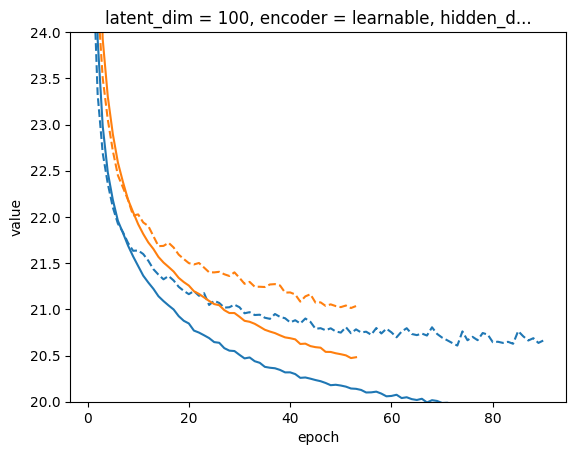

In [28]:
#del min_coords["epoch"]
ds.sel(min_coords).value.sel(loss = 'LM NRGY', mode = 'train', learn_rate=0.0001).plot(label = "Train", color = "tab:blue")
ds.sel(min_coords).value.sel(loss = 'LM NRGY', mode = 'test', learn_rate=0.0001).plot(label = "Validation", color = "tab:blue", linestyle="--")
plt.ylim(20,24)

ds.sel(min_coords).value.sel(loss = 'LM NRGY', mode = 'train', learn_rate=0.00005).plot(label = "Train", color = "tab:orange")
ds.sel(min_coords).value.sel(loss = 'LM NRGY', mode = 'test', learn_rate=0.00005).plot(label = "Validation", color = "tab:orange", linestyle="--")


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(stacked_all.sizes["config"]):
    coords = stacked_all.config[i].item()  # tuple of coordinate values
    #label = ", ".join(f"{dim}={val}" for dim, val in zip(config_dims_all, coords))

    ax.plot(
        stacked_all["epoch"],
        stacked_all.isel(config=i),
        alpha=0.7,
        #label=label
    )

for i in range(stacked_0001.sizes["config"]):
    ax.plot(
    stacked_0001["epoch"],
    stacked_0001.isel(config=i),
    alpha=0.5,
    color="tab:blue"
    )



for i in range(stacked_00005.sizes["config"]):
    ax.plot(
    stacked_00005["epoch"],
    stacked_00005.isel(config=i),
    alpha=0.5,
    color="tab:orange"
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Value")
ax.set_title("All Configurations Over Epochs")
ax.grid()

# Place legend outside
#ax.legend(
#    bbox_to_anchor=(1.02, 1),
#    loc="upper left",
#    borderaxespad=0.,
#    fontsize=7
#)

plt.ylim(20,30)
#plt.xlim(0,50)
plt.tight_layout()
plt.show()

In [84]:
min_point = loss_sub_lr0001.where(loss_sub_lr0001 == loss_sub_lr0001.min(), drop=True)

min_value = min_point.item()
min_coords = {dim: min_point.coords[dim].item() for dim in loss_sub_lr0001.dims}
print(min_point.values)
print(min_coords)

[[[[[[[[[[[20.897]]]]]]]]]]]
{'latent_dim': 100, 'encoder': 'learnable', 'hidden_dim_NN': 100, 'num_layers_NN': 6, 'noise_dim_dec': 5, 'hidden_dim_lm': 50, 'noise_dim_lm': 20, 'lamb': 0.5, 'epoch': 36, 'batch_norm': 'False', 'alpha': 1.5}


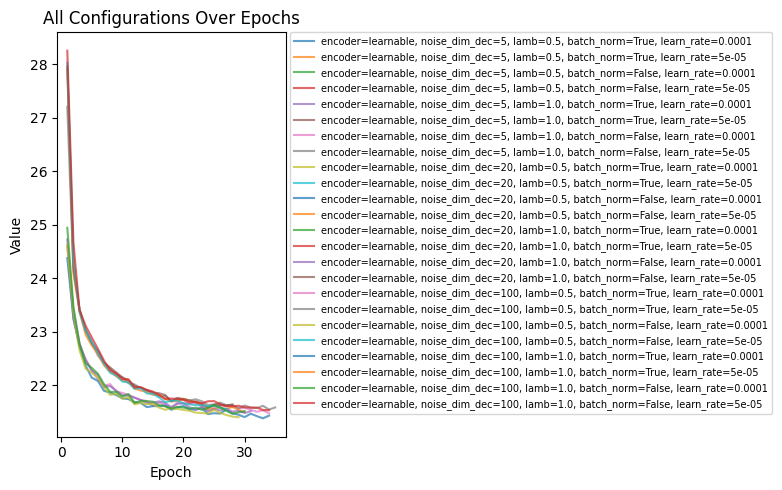

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(stacked.sizes["config"]):
    coords = stacked.config[i].item()  # tuple of coordinate values
    label = ", ".join(f"{dim}={val}" for dim, val in zip(config_dims, coords))

    ax.plot(
        stacked["epoch"],
        stacked.isel(config=i),
        alpha=0.7,
        label=label
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Value")
ax.set_title("All Configurations Over Epochs")

# Place legend outside
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.,
    fontsize=7
)

plt.tight_layout()
plt.show()


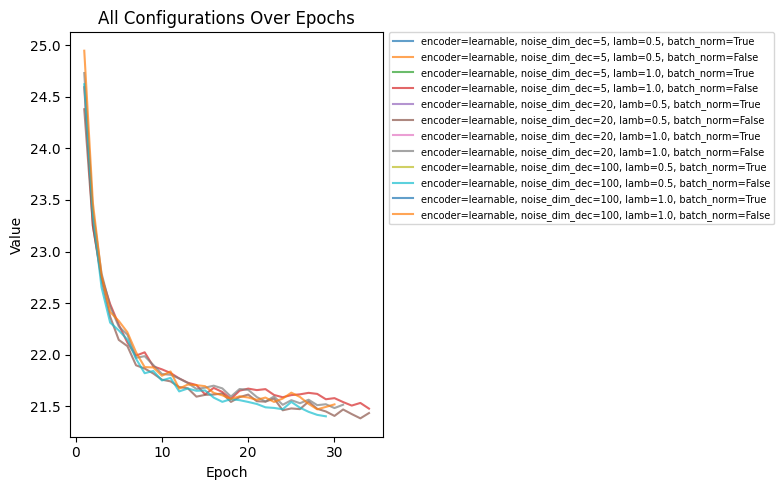

In [85]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(stacked.sizes["config"]):
    coords = stacked.config[i].item()  # tuple of coordinate values
    label = ", ".join(f"{dim}={val}" for dim, val in zip(config_dims, coords))

    ax.plot(
        stacked["epoch"],
        stacked.isel(config=i),
        alpha=0.7,
        label=label
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Value")
ax.set_title("All Configurations Over Epochs")

# Place legend outside
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.,
    fontsize=7
)

plt.tight_layout()
plt.show()
